In [19]:
%pip install neuron
from neuron.units import mV,ms,um # unit definition
from neuron import h, gui
import numpy as np
import plotly
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from scipy.optimize import minimize, differential_evolution


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Build a simple model and simulate a noisy trace for optimization 

In [112]:
# Define all functions
def create_model (Cm,Rm,Ra,plotYN = 1, n_comp = 3,length = 10, diam = 50):
    cmpt = []
    for sec in h.allsec():
        h.delete_section(sec=sec)
    #soma = h.Section (name = 'soma', cell = set)
    for i in range(n_comp):
        sec = h.Section (name=f'dend{i+1}')
        sec.nseg = 10
        sec.L = length
        sec.diam = diam

        sec.insert('pas')
        sec.Ra = Ra
        sec.cm = Cm
        sec.g_pas = 1.0 / Rm
        sec.e_pas = -65
        cmpt.append (sec)
    for i in range(len(cmpt) - 1):
        cmpt[i + 1].connect(cmpt[i])   
    
    if plotYN == 1:
        ps = h.PlotShape (False)
        ps.plot(plotly).show()
    return cmpt

def record_segment(inj_site, current = -0.2, duration= 3250, stim_dur = 1500, delay = 250, init_vm=-65, delta_t=0.05):
    # Set simulation parameters
    h.tstop = duration  # Total duration in ms
    h.v_init = init_vm  # Initial V_m (mV)
    h.dt = delta_t      # Time step for simulation (ms)

    # Create current clamp at the specified segment
    stim = h.IClamp(inj_site)
    stim.delay = delay      # Start of stimulus (ms)
    stim.dur = stim_dur  # Duration of stimulus (ms)
    stim.amp = current   # Amplitude of stimulus (nA)

    # Record membrane potential and time
    v_vec = h.Vector()  # V_m vector
    t_vec = h.Vector()  # Time vector
    recor_site = inj_site
    v_vec.record(recor_site._ref_v)
    t_vec.record(h._ref_t)

    # Initialize and run the simulation
    h.tstop = duration  # Total duration in ms
    h.finitialize(h.v_init)
    h.continuerun(h.tstop)

    return np.array(v_vec), np.array(t_vec)

def add_noise(trace, std_dev=0.1):
    return trace + np.random.normal(0, std_dev, len(trace))

def opt_params (curve2fit, bounds, inj_site, current = -1, fitted_region = None, duration= 3250, 
                stim_dur = 1500, delay = 250, init_vm=-65, delta_t=0.05):   
    mse_val = []
    def obj_function (params):
        Cm, Rm, Ra = params
        print (f"Trying - Ra: {Ra}, cm: {Cm}, Rm: {Rm}")
        for sec in h.allsec():
            sec.insert('pas')
            sec.Ra = Ra
            sec.cm  = Cm
            sec.g_pas = 1/Rm
        v_sim, _ = record_segment(inj_site, current, duration, 
                                  stim_dur, delay, init_vm, delta_t)
        if fitted_region is None:
            mse = np.mean((curve2fit - v_sim) ** 2)
        else:
            start, end = fitted_region
            mse = np.mean((curve2fit[start:end] - v_sim[start:end]) ** 2)

        mse_val.append (mse)
        print (f"MSE: {mse}")
        return mse
    
    result = differential_evolution(obj_function, bounds, maxiter=100, disp = True)
    cm_opt, Rm_opt,Ra_opt = result.x
    print(f"Optimized Ra: {Ra_opt}, Optimized cm: {cm_opt}, Optimized Rm: {Rm_opt}")
    return result, mse_val

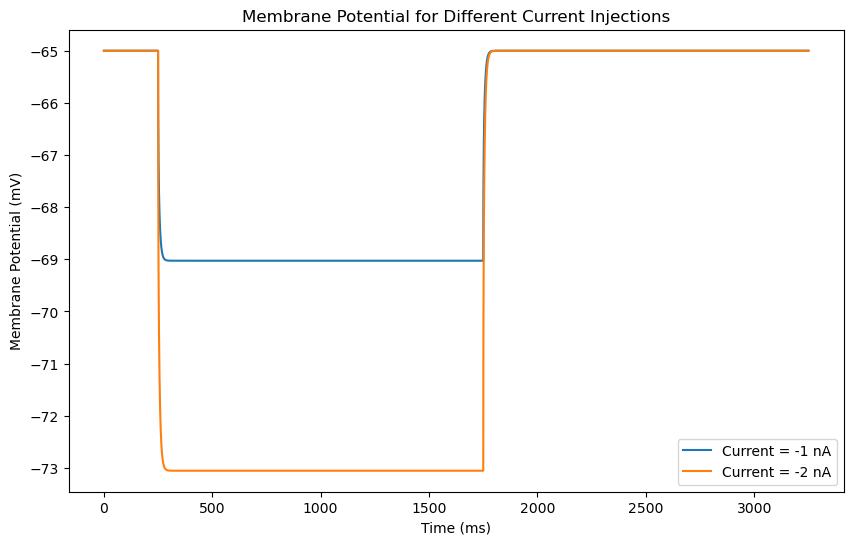

Section name: dend1
  Number of segments (nseg): 10
  Number of nodes: 12
  Length (um): 20.0
  Ra: 60.0
  Cm (um): 1.5
  g_pas (um): 0.00022222222222222223
Section name: dend2
  Number of segments (nseg): 10
  Number of nodes: 12
  Length (um): 20.0
  Ra: 60.0
  Cm (um): 1.5
  g_pas (um): 0.00022222222222222223
Section name: dend3
  Number of segments (nseg): 10
  Number of nodes: 12
  Length (um): 20.0
  Ra: 60.0
  Cm (um): 1.5
  g_pas (um): 0.00022222222222222223
Section name: dend4
  Number of segments (nseg): 10
  Number of nodes: 12
  Length (um): 20.0
  Ra: 60.0
  Cm (um): 1.5
  g_pas (um): 0.00022222222222222223
Section name: dend5
  Number of segments (nseg): 10
  Number of nodes: 12
  Length (um): 20.0
  Ra: 60.0
  Cm (um): 1.5
  g_pas (um): 0.00022222222222222223
Section name: dend6
  Number of segments (nseg): 10
  Number of nodes: 12
  Length (um): 20.0
  Ra: 60.0
  Cm (um): 1.5
  g_pas (um): 0.00022222222222222223
Section name: dend7
  Number of segments (nseg): 10
  Numb

In [123]:
# Model testing (have time constant around 9ms)
R_m = 4500 # ohm cm^2 = ohm m ^10e-4
C_m = 1.5 #uF/cm = F/m 10e-2
tau = R_m * C_m # 6000 ms 
R_a = 60 # ohm cm

test_cmpt = create_model (C_m,R_m,R_a,1,150,20,20) # diameter = 20, n_comp = 150, length for each compt = 20

# injection exp
current_values = [-1, -2]  # nA

all_voltages = []
all_times = []
inj_site = test_cmpt[0](0.5)

# Loop through each current value
for current in current_values:
    v_vec, t_vec = record_segment(inj_site, current=current)
    all_voltages.append(np.array(v_vec))
    all_times.append(np.array(t_vec))

# Plot the results on same graph
plt.figure(figsize=(10, 6))
for i, current in enumerate(current_values):
    plt.plot(all_times[i], all_voltages[i], label=f"Current = {current} nA")

plt.xlabel("Time (ms)")
plt.ylabel("Membrane Potential (mV)")
plt.title("Membrane Potential for Different Current Injections")
plt.legend()
plt.show()

for sec in h.allsec():
        print(f"Section name: {sec.name()}")
        print(f"  Number of segments (nseg): {sec.nseg}")
        print(f"  Number of nodes: {int(sec.n3d())}")
        print(f"  Length (um): {sec.L}")
        print(f"  Ra: {sec.Ra}")
        print(f"  Cm (um): {sec.cm}")
        print (f"  g_pas (um): {sec.g_pas}")


Text(0.5, 1.0, 'Membrane potential with Gaussian noise')

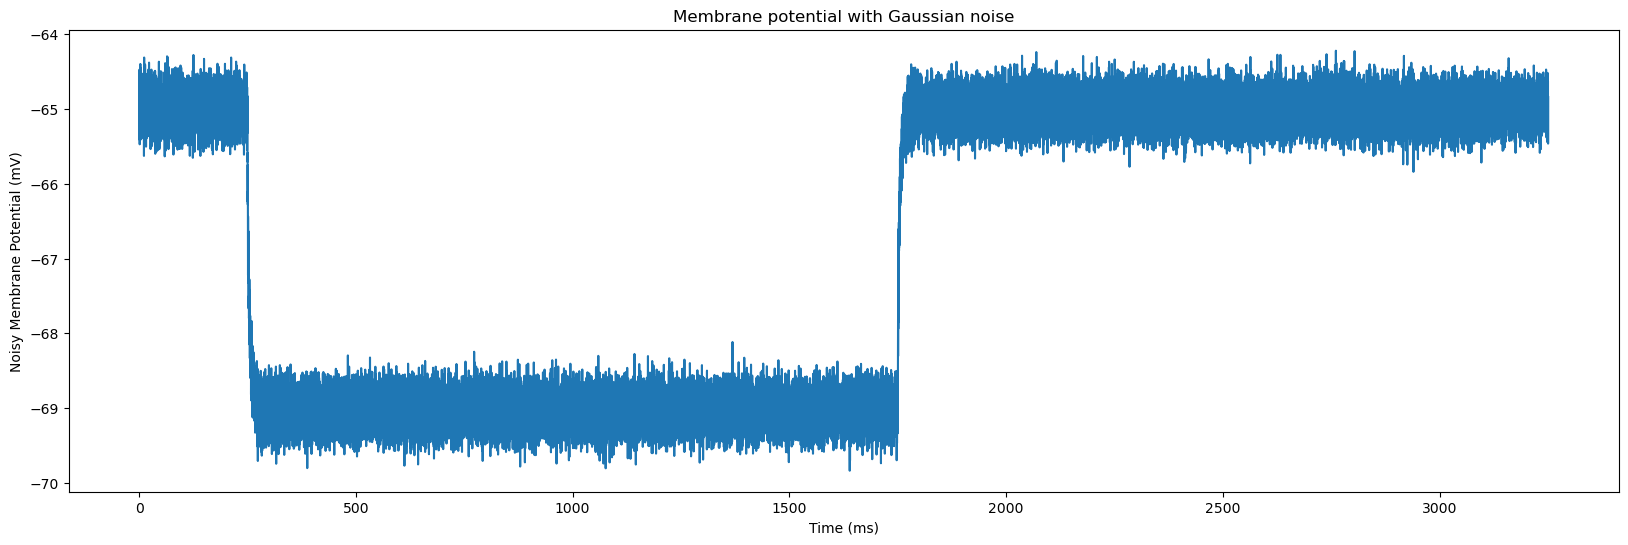

In [118]:
# Add noise
std = 0.2
noisy_trace = add_noise (all_voltages[0],std)
plt.figure(figsize=(20, 6))
plt.plot (all_times[0], noisy_trace)
plt.xlabel("Time (ms)")
plt.ylabel("Noisy Membrane Potential (mV)")
plt.title("Membrane potential with Gaussian noise")

Trying - Ra: 67.27361902153606, cm: 1.765411611911173, Rm: 5714.066498969695
MSE: 0.2139242856035309
Trying - Ra: 54.8181478205563, cm: 1.3401419321579828, Rm: 6779.791404790397
MSE: 1.296794942185307
Trying - Ra: 54.25321718726371, cm: 1.8879772218344737, Rm: 5281.611222989651
MSE: 1.112395341167978
Trying - Ra: 51.74819313316916, cm: 1.4014158579692468, Rm: 6980.284849083472
MSE: 2.0212279006359446
Trying - Ra: 54.96841537202715, cm: 1.233971831730781, Rm: 5075.831624620276
MSE: 1.805643511735497
Trying - Ra: 56.695136565775556, cm: 1.5982395347996436, Rm: 6859.844887426753
MSE: 1.5637614677474416
Trying - Ra: 59.07835044826777, cm: 1.5554615734365007, Rm: 6577.674563118899
MSE: 0.728196864984043
Trying - Ra: 57.45910796023145, cm: 1.1818959773564572, Rm: 6433.694669782118
MSE: 0.44078100948697985
Trying - Ra: 60.94978418428529, cm: 1.502346845829679, Rm: 6309.211595289915
MSE: 0.23739653147925177
Trying - Ra: 68.03386569815993, cm: 1.646268985600141, Rm: 5213.441060166012
MSE: 1.314

Text(0.5, 1.0, 'MSE over iterations')

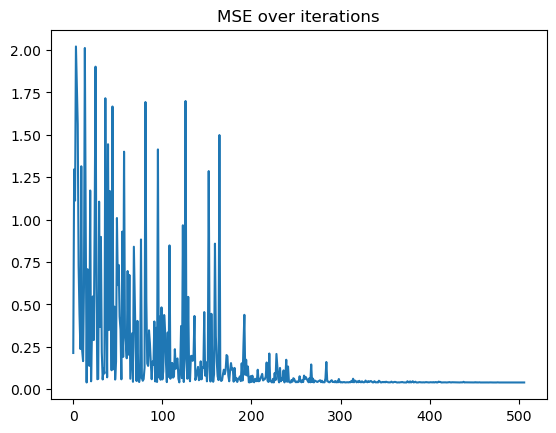

In [54]:
#Cm = 1.5, Rm = 6000, Ra = 60 (Real parameters)
bounds = [(1, 2), (5000, 7000), (50,70)]

parms, mse = opt_params (noisy_trace, bounds, inj_site, current_values[0]) 
plt.plot (mse)
plt.title ('MSE over iterations')

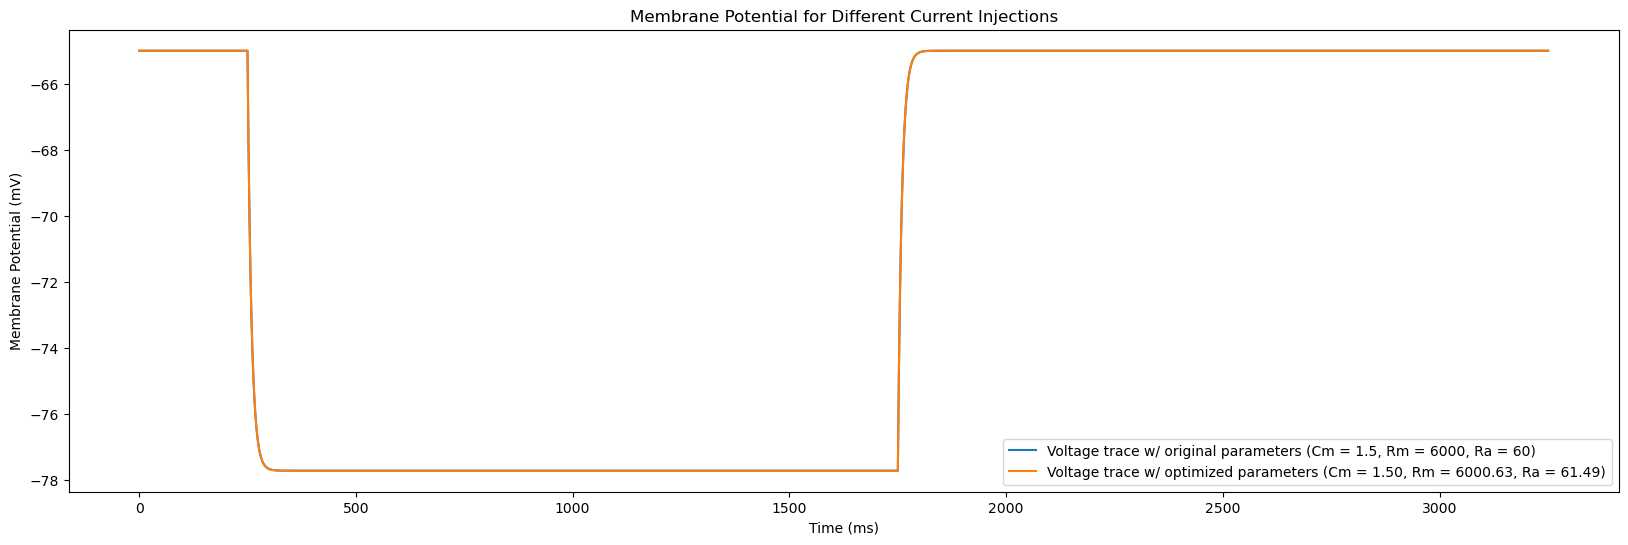

In [24]:
# Plot Optimized model on top of real model
Ra_opt = parms.x[2]; Cm_opt = parms.x[0]; Rm_opt = parms.x[1]

opt_params_cmpt = create_model (Cm_opt,Rm_opt,Ra_opt,0)
v_vec_opt, _ = record_segment(opt_params_cmpt[0](0.5), current=current_values[0])


# Plot the results on same graph
plt.figure(figsize=(20, 6))
plt.plot (all_times[0], all_voltages[0],label=f"Voltage trace w/ original parameters (Cm = {C_m}, Rm = {R_m}, Ra = {R_a})")
plt.plot(all_times[0], v_vec_opt, label=f"Voltage trace w/ optimized parameters (Cm = {Cm_opt:.2f}, Rm = {Rm_opt:.2f}, Ra = {Ra_opt:.2f})")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane Potential (mV)")
plt.title("Membrane Potential for Different Current Injections")
plt.legend()
plt.show()


## Ues experimental data to fit for the simple model

Experimental Time and length (603)
Experimental Voltage and length (603)


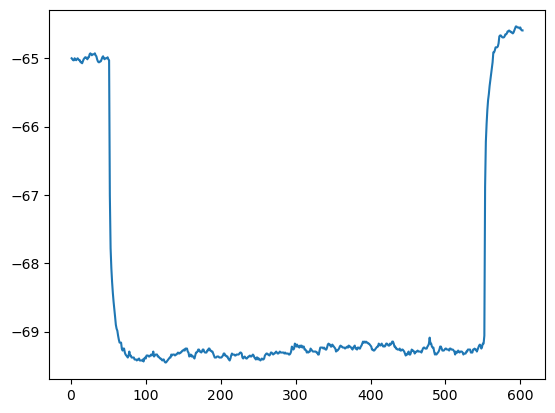

In [113]:
# Import experimental data
import pandas as pd
path = '/Users/samme/Library/CloudStorage/OneDrive-Emory/Lab/LGMD_project/LGMD_Data/Passive_CurrentClamp/um1na.csv'
data = pd.read_csv(path, header=None)
exp_t= data[0].values        # First column for time
exp_v = data[1].values  # Second column for voltage

# Verify the arrays
print(f"Experimental Time and length ({len(exp_t)})")
print(f"Experimental Voltage and length ({len(exp_v)})")
plt.plot (range (1,  len(exp_t)+ 1), exp_v)

Trying - Ra: 80.57942371467988, cm: 1.3732184191436838, Rm: 3328.2313323308363
MSE: 0.2792886617680335
Trying - Ra: 79.21987063468606, cm: 1.2282987824528533, Rm: 5617.103361831255
MSE: 0.6971191428329618
Trying - Ra: 35.86984458916251, cm: 1.4466019083297998, Rm: 17811.97870873199
MSE: 37.05754975057014
Trying - Ra: 29.132734358275236, cm: 1.6355333830116576, Rm: 10389.131590035033
MSE: 4.275020357707437
Trying - Ra: 41.87123897118887, cm: 1.6012070536307097, Rm: 16733.21257748392
MSE: 32.3813442831479
Trying - Ra: 40.01830930434687, cm: 1.6486856234191944, Rm: 15889.866116418492
MSE: 27.06832213223102
Trying - Ra: 68.20891119500351, cm: 0.6663652885816949, Rm: 13165.111312295507
MSE: 22.139359318606868
Trying - Ra: 53.08250484398788, cm: 0.8096409683984913, Rm: 16980.562028091477
MSE: 39.52331096774798
Trying - Ra: 69.89034406970417, cm: 1.0336093090605247, Rm: 8196.029847885078
MSE: 4.20600901338324
Trying - Ra: 57.19516052099327, cm: 0.9546582694126944, Rm: 19243.898175619695
MSE: 

Text(0.5, 1.0, 'MSE over iterations')

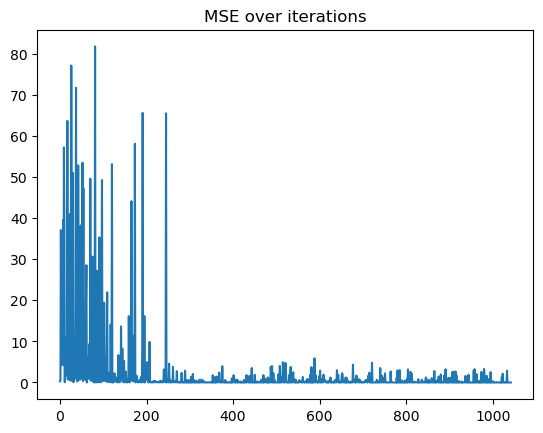

In [124]:
exp_delt = 1 #ms
region = [80,500]
# Cm, Rm, Ra
bounds = [(0.5, 1.75), (2000, 20000), (20,100)]

parms, mse = opt_params (exp_v, bounds, inj_site, current = -1, fitted_region = region, duration= 2000, 
                stim_dur = 1500, delay = 50, init_vm=-65, delta_t= exp_delt)

plt.plot (mse)
plt.title ('MSE over iterations')


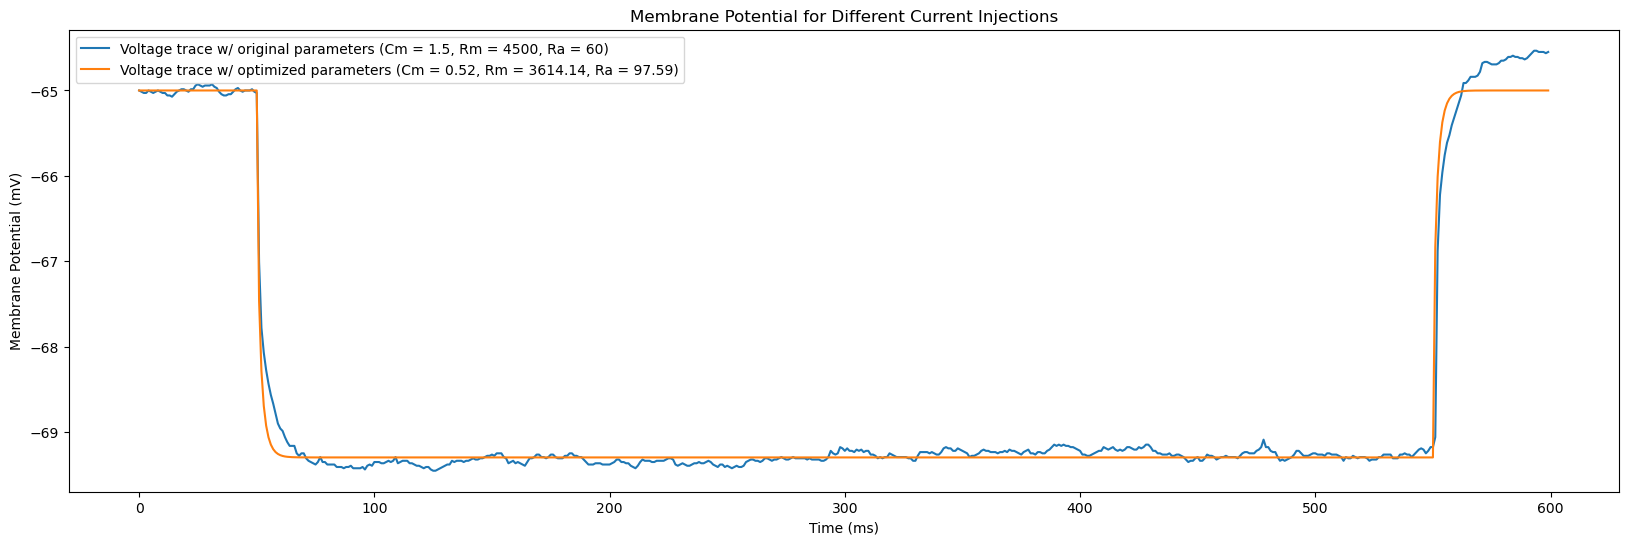

In [127]:
# flot experimental vs. optimized data
Ra_opt = parms.x[2]; Cm_opt = parms.x[0]; Rm_opt = parms.x[1]

opt_params_cmpt = create_model (Cm_opt,Rm_opt,Ra_opt,0,150,20,20)
v_vec_opt, _ = record_segment(opt_params_cmpt[0](0.5), -1,599,500,50,-65,1)

# Plot the results on same graph
plt.figure(figsize=(20, 6))
plt.plot (range (600), exp_v[:600],label=f"Voltage trace w/ original parameters (Cm = {C_m}, Rm = {R_m}, Ra = {R_a})")
plt.plot(range (600), v_vec_opt, label=f"Voltage trace w/ optimized parameters (Cm = {Cm_opt:.2f}, Rm = {Rm_opt:.2f}, Ra = {Ra_opt:.2f})")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane Potential (mV)")
plt.title("Membrane Potential for Different Current Injections")
plt.legend()
plt.show()